# Generowanie obrazu z interwencją

Notatnik ilustruje wykorzystanie modelu Stable Diffusion 1.4 z autoenkoderem wytrenowanym metodą minimalizacji przewidywalności do wykonania interwencji w generację obrazu

* Autoenkoder dekomponuje aktywacje pewnej warstwy modelu dyfuzyjnego do rzadkiej reprezentacji (nazywanej słownikiem)
* Użytkownik podaje mnożniki per wymiar słownika
* Zmodyfikowana reprezentacja słownikowa zostaje zdekodowana
* Generacja jest kontynuowana ze zmienionymi aktywacjami

In [1]:
!git clone https://github.com/mGarbowski/zzsn-projekt.git
!cd zzsn-projekt && git checkout intervention

Cloning into 'zzsn-projekt'...
remote: Enumerating objects: 434, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 434 (delta 63), reused 80 (delta 21), pack-reused 265 (from 1)
Receiving objects: 100% (434/434), 10.16 MiB | 11.60 MiB/s, done.
Resolving deltas: 100% (199/199), done.
Branch 'intervention' set up to track remote branch 'intervention' from 'origin'.
Switched to a new branch 'intervention'


In [2]:
import os
os.chdir('zzsn-projekt')
os.getcwd()

'/content/zzsn-projekt'

In [3]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

## Załadowanie modelu
* Domyślnie wykorzystywany jest model `CompVis/stable-diffusion-v1-4`
* Wagi autoenkodera są pobierane z W&B

In [4]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mikolaj-garbowski (mikolaj-garbowski-warsaw-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
from models.diffusion import WrappedDiffusion
import torch

wrapped_diffusion = WrappedDiffusion.from_pretrained(
    schmidhuber_artifact_id="mikolaj-garbowski-warsaw-university-of-technology/zzsn-projekt/model-ms3nxq87-epoch_2:v0",
    device=device,
    torch_dtype=torch.float16,
    safety_checker=None
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its result

## Generujemy obrazy z tymi samymi parametrami, wykonując interwencję w aktywacjach modelu dyfuzyjnego

In [6]:
from models.diffusion import GenerationParams
params = GenerationParams(
    prompts=["A picture of a british shorthair cat"],
    num_seeds=1,
    num_inference_steps=50,
    guidance_scale=7.5
)

## Obraz bez interwencji

In [7]:
result_no_intervention = wrapped_diffusion.generate(params)

  0%|          | 0/50 [00:00<?, ?it/s]

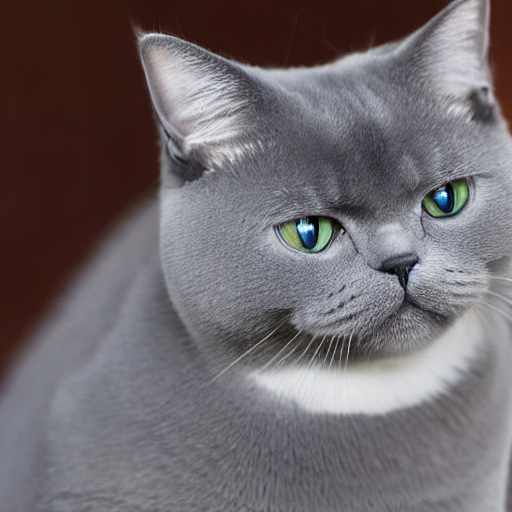

In [8]:
result_no_intervention[0].image

## Wyzerowanie wybranych wymiarów słownika

In [9]:
multipliers = {
    key: 0 for key in range(10, 50)
}
result_with_intervention = wrapped_diffusion.generate_with_intervention(params, multipliers)

  0%|          | 0/50 [00:00<?, ?it/s]

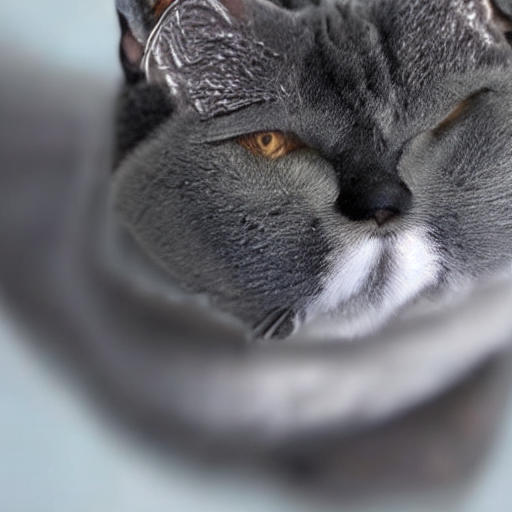

In [10]:
result_with_intervention[0].image

  0%|          | 0/50 [00:00<?, ?it/s]

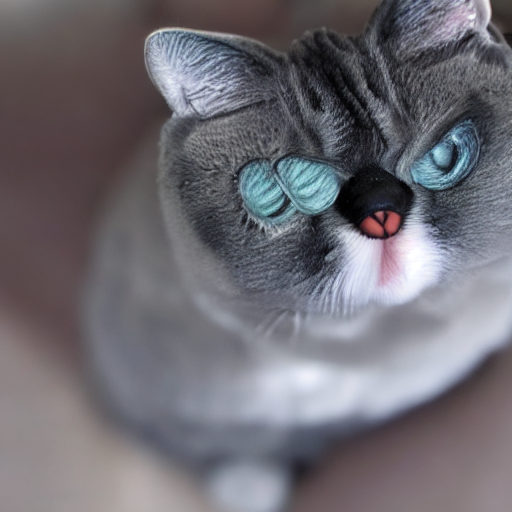

In [11]:
multipliers = {
    100: 0,
    101: 0
}
result = wrapped_diffusion.generate_with_intervention(params, multipliers)[0]
result.image

  0%|          | 0/50 [00:00<?, ?it/s]

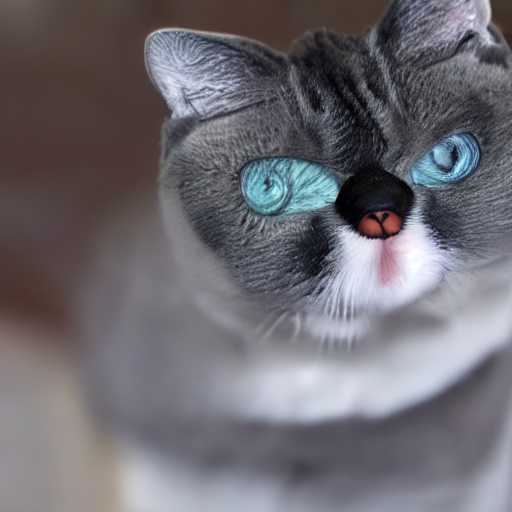

In [12]:
multipliers = {
    1000: 0
}
result = wrapped_diffusion.generate_with_intervention(params, multipliers)[0]
result.image

## Wzmocnienie wybranego wymiaru

  0%|          | 0/50 [00:00<?, ?it/s]

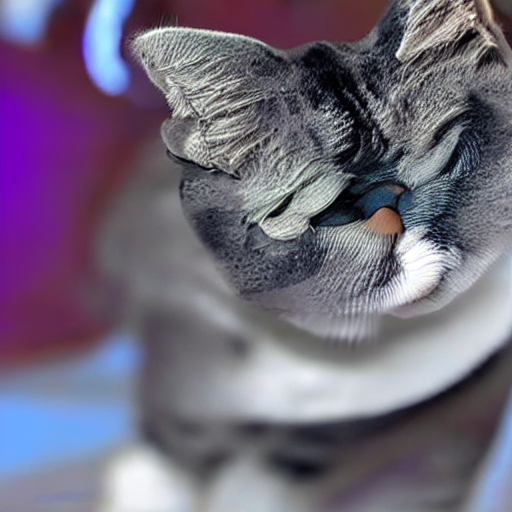

In [13]:
multipliers = {
    1000: 10
}
result = wrapped_diffusion.generate_with_intervention(params, multipliers)[0]
result.image

  0%|          | 0/50 [00:00<?, ?it/s]

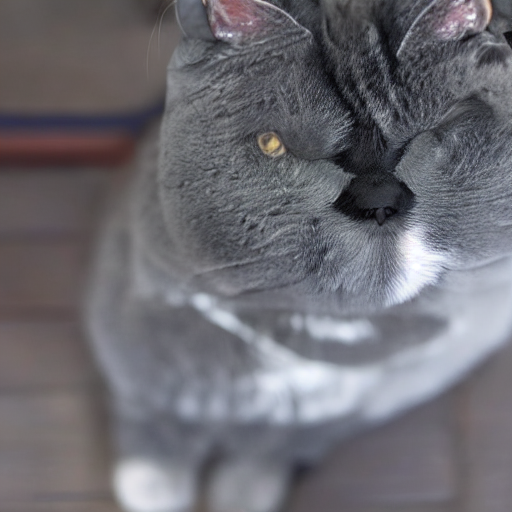

In [14]:
multipliers = {
    0: 5
}
result = wrapped_diffusion.generate_with_intervention(params, multipliers)[0]
result.image

## Komentarz
* Użyty autoenkoder jest jeszcze niewystarczająco dobrze wytrenowany, obrazy po interwencji są nienaturalne i przestawiają coś co przypomina oryginalny obraz, ale bardzo zdeformowany
* Dalsze kroki projektu obejmą zidentyfikowanie interesujących, dających się zinterpretować wymiarów słownika oraz dostrojenie hiperparametrów treningu autoenkodera
* Ten notatnik jedynie demonstruje API i sposób użycia modelu do wykonania interwencji